# Machine Learning Midterm Assignment #
This assignment predicts whether each employee resigned using the `resign.csv` dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, precision_recall_curve

In [2]:
# Access to the file
df = pd.read_csv('resign.csv')
df.info() # Check data information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   satisfaction  14999 non-null  float64
 1   evaluation    14999 non-null  float64
 2   project       14999 non-null  int64  
 3   workhour      14999 non-null  int64  
 4   years         14999 non-null  int64  
 5   accident      14999 non-null  int64  
 6   resign        14999 non-null  int64  
 7   promotion     14999 non-null  int64  
dtypes: float64(2), int64(6)
memory usage: 937.6 KB


# (1) Check the class proportions of the resign variable and explain whether the dataset is imbalanced.

In [3]:
print("Resign counts:", df['resign'].value_counts())
print("Resign proportion:", df['resign'].value_counts(normalize=True))

Resign counts: resign
0    11428
1     3571
Name: count, dtype: int64
Resign proportion: resign
0    0.761917
1    0.238083
Name: proportion, dtype: float64


### Interpretation
The target variable `resign` is imbalanced because the number of employees who did not resign (11,428 people, about 76.2%) is larger than the number of employees who resigned (3,571 people, about 23.8%). Therefore, using stratified sampling when splitting the data into training and test sets is reasonable.

# (2) Randomly split the full dataset into tr 80%, ts 20%. Use stratified sampling. Also, if necessary, apply a method to address class imbalance, such as under-sampling.

In [4]:
#Set features as X, except for a target variable, 'resign' as y.
X = df.drop('resign', axis=1)
y = df['resign']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

print("Before under-sampling:")
print(y_train.value_counts())

# Apply under-sampling only to the training data
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=0)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("After under-sampling:")
print(pd.Series(y_train_under).value_counts())

Before under-sampling:
resign
0    9142
1    2857
Name: count, dtype: int64
After under-sampling:
resign
0    2857
1    2857
Name: count, dtype: int64


### Interpretation
After splitting the data into training and test sets using stratified sampling, I applied under-sampling only to the training data in order to reduce the effect of imbalanced data.
On the other hand, the test set was not under-sampled because it should reflect the original data distribution. This allows the models to be evaluated on data that is closer to the real situation.

# (3) Train a Logistic Regression model using the training data.

In [5]:
from sklearn.linear_model import LogisticRegression
lr_under = LogisticRegression(max_iter=1000, random_state=0)
lr_under.fit(X_train_under, y_train_under)
coeff_under = pd.Series(
    data=np.round(lr_under.coef_[0], decimals=4),
    index=['satisfaction', 'evaluation','project','workhour','years','accident','promotion'])
print("Coefficient:")
print(coeff_under)

y_pred_under = lr_under.predict(X_test)
y_pred_proba_under = lr_under.predict_proba(X_test)

# Check accuracy, precision, recall and f1 scores
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_under))
print("Classification Report:")
print(classification_report(y_test, y_pred_under))

Coefficient:
satisfaction   -4.2368
evaluation      0.8500
project        -0.3981
workhour        0.0051
years           0.4638
accident       -1.5674
promotion      -1.8054
dtype: float64
Confusion Matrix:
[[1715  571]
 [ 146  568]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      2286
           1       0.50      0.80      0.61       714

    accuracy                           0.76      3000
   macro avg       0.71      0.77      0.72      3000
weighted avg       0.82      0.76      0.78      3000



### Interpretation
The Logistic Regression model was trained using the under-sampled training data. The coefficients show the direction of the relationship between each feature and the probability of resignation.
For example, positive coefficients, such as `years`, indicate an increase in the predicted probability of resignation, while negative coefficients, such as `satisfaction`, indicate a decrease in the predicted probability of resignation. However, because the variables are measured on different scales, the magnitudes of the coefficients should not be directly compared.

On the original test set, the model achieved a recall of 0.80 (568/(568+146)) and an F1 score of 0.61 for class 1. This means that the model identified many employees who actually resigned. However, the precision for class 1 was 0.50 (568/(568+571)), meaning that many employees predicted as resigned did not actually resign.

Therefore, the Logistic Regression model is useful for detecting resigned employees, but it also produces many false positives in this case. The model performance will be compared with the other models later in (9).

# (4) Train a Decision Tree model using the training data. For hyperparameters that need tuning, apply 5-fold cross-validation

In [6]:
print("Missing values:")
print(df.isnull().any(axis=0)) ## Check missing values. False means no missing values.

print("Summary statistics:")
print(df.describe()) ## basic summary statistics to check the range of each variable.

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV

parameters = {'max_depth': [3,4,5], 'min_samples_split' : [300, 500, 1000]}
dt_rsg = DecisionTreeClassifier(random_state=0)
grid_dt = GridSearchCV(dt_rsg, param_grid=parameters, cv=5, scoring='f1', refit=True)
grid_dt.fit(X_train_under, y_train_under)
scores_df = pd.DataFrame(grid_dt.cv_results_) # cross-validation results

print("Cross-validation results:")
print(scores_df[['params', 'rank_test_score']])
print("Best parameters:", grid_dt.best_params_)
print("Best CV F1 score:", grid_dt.best_score_)

dt_update = grid_dt.best_estimator_
y_pred_under_dt = dt_update.predict(X_test)
print("Test F1 score of Decision Tree:", f1_score(y_test, y_pred_under_dt))

print("Classification Report of Decision Tree:")
print(classification_report(y_test, y_pred_under_dt))

Missing values:
satisfaction    False
evaluation      False
project         False
workhour        False
years           False
accident        False
resign          False
promotion       False
dtype: bool
Summary statistics:
       satisfaction    evaluation       project      workhour         years  \
count  14999.000000  14999.000000  14999.000000  14999.000000  14999.000000   
mean       0.612834      0.716102      3.803054    201.050337      3.498233   
std        0.248631      0.171169      1.232592     49.943099      1.460136   
min        0.090000      0.360000      2.000000     96.000000      2.000000   
25%        0.440000      0.560000      3.000000    156.000000      3.000000   
50%        0.640000      0.720000      4.000000    200.000000      3.000000   
75%        0.820000      0.870000      5.000000    245.000000      4.000000   
max        1.000000      1.000000      7.000000    310.000000     10.000000   

           accident        resign     promotion  
count  14999.0

### Interpretation
For the Decision Tree model, I used 5-fold cross-validation to tune the hyperparameters `max_depth` and `min_samples_split`. The best model used `max_depth=5` and `min_samples_split=300`. This means that the selected tree is limited in depth and requires at least 300 samples to split an internal node, which helps reduce overfitting.
The final Decision Tree model was refitted using the best parameters and evaluated on the original test set. The best CV F1 score was 0.9251, and the F1 score on the test set was 0.872. Since the test F1 score is also high, the selected Decision Tree model performs well on unseen data.
Further analysis will be provided in the following questions.

# (5) Visualize the tree obtained from the result of (4) and interpret it.

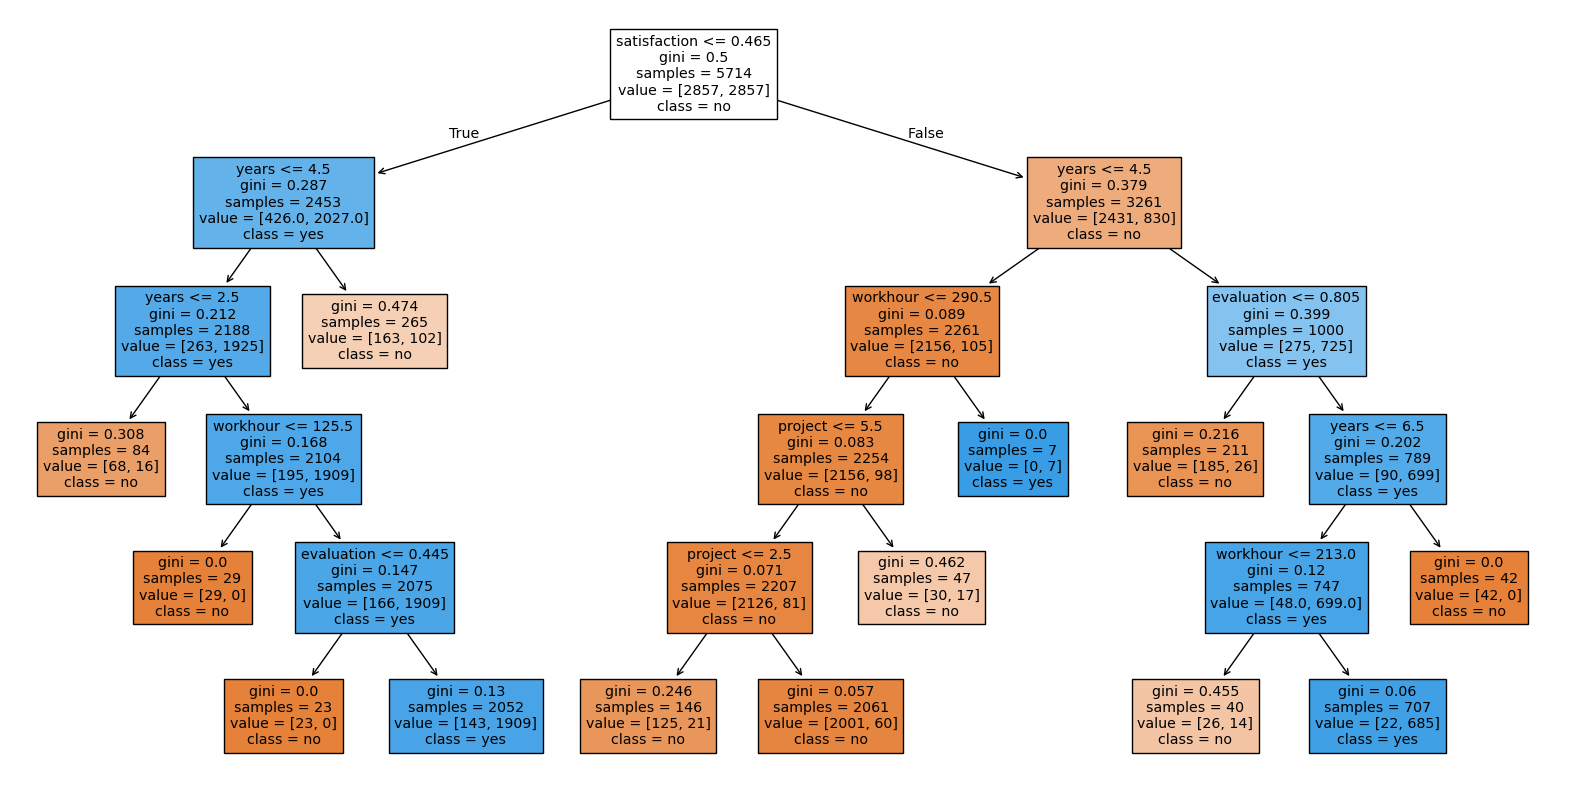

In [7]:
fig = plt.figure(figsize=(20,10))
plot_tree(dt_update, feature_names=X.columns, class_names=['no','yes'], filled=True);

### Interpretation
The first split of the decision tree is based on `satisfaction <= 0.465`, indicating that satisfaction is the most important variable for predicting resignation in this tree. Employees with `satisfaction <= 0.465` are generally more likely to be classified as resigned. In particular, employees with low satisfaction, relatively short years at the company, `workhour > 125.5`, and `evaluation > 0.445` are highly likely to resign (1,909 people). This suggests that low satisfaction is strongly associated with resignation.
On the other hand, employees with `satisfaction > 0.465` are generally classified as non-resigned. However, the tree also identifies another high-risk group within this branch. Employees with `years > 4.5`, `evaluation <= 0.805`, `years <= 6.5`, and `workhour > 213.0` are likely to be classified as resigned (685 people).
Overall, the decision tree suggests that resignation is mainly related to low satisfaction, but it can also occur among employees with higher satisfaction when they have longer tenure, relatively lower evaluation scores, and high workload.

# (6) Train a Random Forest model using training data. For hyperparameters that need tuning, apply 5-fold cross-validation

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

parameters = {'n_estimators': [100, 300, 500],
              'max_depth': [3,4,5],
              'min_samples_split': [300, 500, 1000]}
rf_rsg = RandomForestClassifier(random_state=0, oob_score=True, bootstrap=True)
grid_rf = GridSearchCV(rf_rsg, param_grid=parameters, cv=5, scoring='f1', refit=True)
grid_rf.fit(X_train_under, y_train_under)
scores_rf = pd.DataFrame(grid_rf.cv_results_) # cross-validation results

print("Cross-validation results:")
print(scores_rf[['params', 'rank_test_score']])
print("Best parameters:", grid_rf.best_params_)
print("Best CV F1 score:", grid_rf.best_score_)

rf_update = grid_rf.best_estimator_ # Best random forest model from GridSearchCV
y_pred_under_rf = rf_update.predict(X_test)
print("Test F1 score of Random Forest:", f1_score(y_test, y_pred_under_rf))

print("Classification Report of Random Forest:")
print(classification_report(y_test, y_pred_under_rf))

Cross-validation results:
                                               params  rank_test_score
0   {'max_depth': 3, 'min_samples_split': 300, 'n_...               17
1   {'max_depth': 3, 'min_samples_split': 300, 'n_...               15
2   {'max_depth': 3, 'min_samples_split': 300, 'n_...               13
3   {'max_depth': 3, 'min_samples_split': 500, 'n_...               16
4   {'max_depth': 3, 'min_samples_split': 500, 'n_...               18
5   {'max_depth': 3, 'min_samples_split': 500, 'n_...               14
6   {'max_depth': 3, 'min_samples_split': 1000, 'n...               25
7   {'max_depth': 3, 'min_samples_split': 1000, 'n...               26
8   {'max_depth': 3, 'min_samples_split': 1000, 'n...               27
9   {'max_depth': 4, 'min_samples_split': 300, 'n_...               12
10  {'max_depth': 4, 'min_samples_split': 300, 'n_...                5
11  {'max_depth': 4, 'min_samples_split': 300, 'n_...                7
12  {'max_depth': 4, 'min_samples_split': 500, 'n_.

### Interpretation
For the Random Forest model, I used 5-fold cross-validation to tune `n_estimators`, `max_depth`, and `min_samples_split`. The best parameters `n_estimators=300`, `max_depth=5`, and `min_samples_split=300` were used based on the F1 score. The best CV F1 score was 0.948, and the test F1 score was 0.934. Since the test F1 score is also high, the selected Random Forest model performs well on unseen data.
Compared with a single Decision Tree (CV F1=0.925, test F1=0.872), Random Forest combines multiple decision trees, so it can make more stable predictions and reduce the effect of one unstable tree.
The final Random Forest model was refitted using the best parameters and evaluated on the original test set. The test F1 score will be compared with the other models later in (9).

# (7) From the result of (6), obtain the feature importance values for each variable and interpret them.

Feature importance values:
satisfaction    0.312644
years           0.254206
project         0.167002
workhour        0.140449
evaluation      0.114974
accident        0.010119
promotion       0.000607
dtype: float64


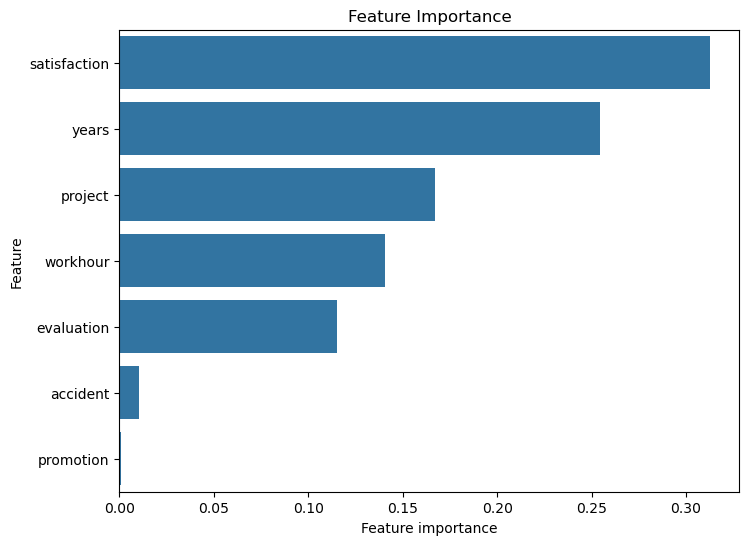

In [9]:
feature_importances = np.mean([tree.feature_importances_ for tree in rf_update.estimators_], axis=0)

import seaborn as sns
imp_values = feature_importances
imp_values = pd.Series(imp_values, index=X_train_under.columns)
imp_values = imp_values.sort_values(ascending=False)
print("Feature importance values:")
print(imp_values)

plt.figure(figsize=(8,6))
plt.title('Feature Importance')
sns.barplot(x=imp_values, y=imp_values.index)
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.show()

### Interpretation
The feature importance results show that `satisfaction` is the most important variable in the Random Forest model (0.3126). This means that satisfaction contributed the most to predicting employee resignation in the model. `years` (0.2542) was the second most important variable, followed by `project` (0.1670), `workhour` (0.1404), and `evaluation` (0.1150). In contrast, `accident` and `promotion` had very low importance values, suggesting that they contributed little to the model's prediction.
Overall, the Random Forest model suggests that employee resignation is mainly associated with `satisfaction`, `years` at the company, the number of `projects`, `working hours`, and `evaluation`. However, it is noteworthy that feature importance does not imply causality. It only shows the relative contribution of each variable to prediction.

# (8) Train an AdaBoost model using the training data. For the hyperparameters that need tuning, apply 5-fold cross-validation on the training data.

In [10]:
from sklearn.ensemble import AdaBoostClassifier

parameters = {'n_estimators': [100, 300, 500], 'estimator__max_depth': [1,2,3]}
ada_rsg = AdaBoostClassifier(DecisionTreeClassifier(random_state=0), random_state=0)
grid_ada = GridSearchCV(ada_rsg, param_grid=parameters, cv=5, scoring='f1', refit=True)
grid_ada.fit(X_train_under, y_train_under)
scores_ada = pd.DataFrame(grid_ada.cv_results_) # cross-validation results

print("Cross-validation results:")
print(scores_ada[['params', 'rank_test_score']])
print("Best parameters:", grid_ada.best_params_)
print("Best CV F1 score:", grid_ada.best_score_)

ada_update = grid_ada.best_estimator_
y_pred_under_ada = ada_update.predict(X_test)
print("Test F1 score of AdaBoost:", f1_score(y_test, y_pred_under_ada))

print("Classification Report of AdaBoost:")
print(classification_report(y_test, y_pred_under_ada))

Cross-validation results:
                                             params  rank_test_score
0  {'estimator__max_depth': 1, 'n_estimators': 100}                9
1  {'estimator__max_depth': 1, 'n_estimators': 300}                8
2  {'estimator__max_depth': 1, 'n_estimators': 500}                7
3  {'estimator__max_depth': 2, 'n_estimators': 100}                6
4  {'estimator__max_depth': 2, 'n_estimators': 300}                5
5  {'estimator__max_depth': 2, 'n_estimators': 500}                4
6  {'estimator__max_depth': 3, 'n_estimators': 100}                3
7  {'estimator__max_depth': 3, 'n_estimators': 300}                2
8  {'estimator__max_depth': 3, 'n_estimators': 500}                1
Best parameters: {'estimator__max_depth': 3, 'n_estimators': 500}
Best CV F1 score: 0.9641558061016559
Test F1 score of AdaBoost: 0.9354395604395604
Classification Report of AdaBoost:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98  

### Interpretation
For the AdaBoost model, I used 5-fold cross-validation to tune `n_estimators` and the `maximum depth` of the base decision tree. The best hyperparameters, `n_estimators=500` and `estimator__max_depth=3` were selected based on the F1 score. The best CV F1 score was 0.964., and the test F1 score was 0.935.
The final AdaBoost model was refitted using the best parameters and evaluated on the original test set.
Since the test F1 score is also high, the selected AdaBoost model performs well on unseen data. This result will be compared with the other models in (9).

# (9) Using the test data, compare the performance of the models from (3), (4), (6), and (8). For model comparison, use precision, recall, F1 score, and the precision-recall curve.

                 Model  Precision    Recall  F1 Score
0  Logistic Regression   0.498683  0.795518  0.613060
1        Decision Tree   0.832061  0.915966  0.872000
2        Random Forest   0.945481  0.922969  0.934089
3             AdaBoost   0.917790  0.953782  0.935440


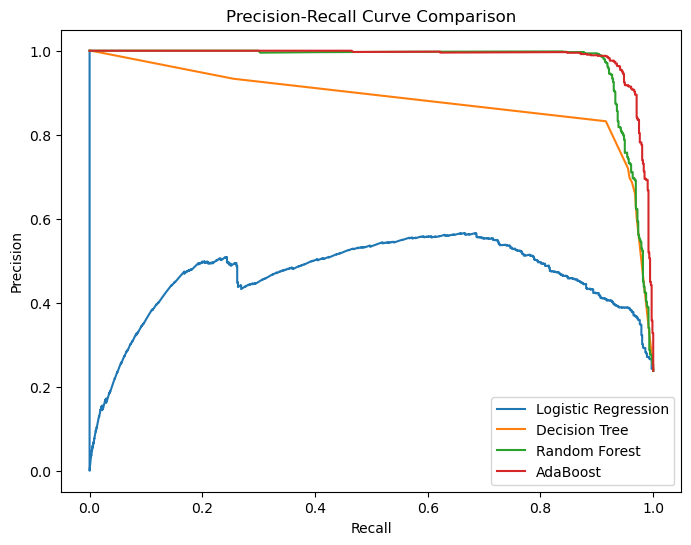

In [11]:
# Predictions
y_pred_under_lr = lr_under.predict(X_test)
y_pred_under_dt = dt_update.predict(X_test)
y_pred_under_rf = rf_update.predict(X_test)
y_pred_under_ada = ada_update.predict(X_test)

# Predicted probabilities for class 1
y_proba_under_lr = lr_under.predict_proba(X_test)[:, 1]
y_proba_under_dt = dt_update.predict_proba(X_test)[:, 1]
y_proba_under_rf = rf_update.predict_proba(X_test)[:, 1]
y_proba_under_ada = ada_update.predict_proba(X_test)[:, 1]

# Compare precision, recall, and F1 score
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'AdaBoost'],
    'Precision': [
        precision_score(y_test, y_pred_under_lr),
        precision_score(y_test, y_pred_under_dt),
        precision_score(y_test, y_pred_under_rf),
        precision_score(y_test, y_pred_under_ada)],
    'Recall': [
        recall_score(y_test, y_pred_under_lr),
        recall_score(y_test, y_pred_under_dt),
        recall_score(y_test, y_pred_under_rf),
        recall_score(y_test, y_pred_under_ada)],
    'F1 Score': [
        f1_score(y_test, y_pred_under_lr),
        f1_score(y_test, y_pred_under_dt),
        f1_score(y_test, y_pred_under_rf),
        f1_score(y_test, y_pred_under_ada)]})
print(model_comparison)

# Precision-Recall curves for all models
plt.figure(figsize=(8, 6))

prec_lr, rec_lr, thres_lr = precision_recall_curve(y_test, y_proba_under_lr)
plt.plot(rec_lr, prec_lr, label='Logistic Regression')

prec_dt, rec_dt, thres_dt = precision_recall_curve(y_test, y_proba_under_dt)
plt.plot(rec_dt, prec_dt, label='Decision Tree')

prec_rf, rec_rf, thres_rf = precision_recall_curve(y_test, y_proba_under_rf)
plt.plot(rec_rf, prec_rf, label='Random Forest')

prec_ada, rec_ada, thres_ada = precision_recall_curve(y_test, y_proba_under_ada)
plt.plot(rec_ada, prec_ada, label='AdaBoost')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.show()

### Interpretation
The models were compared using precision, recall, and F1 score on the original test set.
`The Logistic Regression` model had the lowest F1 score (0.6131), mainly because its precision was relatively low (0.4987). `The Decision Tree` model performed much better than `Logistic Regression`, with an F1 score of 0.8720.
`Random Forest` (F1, 0.9341) and `AdaBoost` (F1, 0.9354) showed the best performance among the four models. `Random Forest` had higher precision (0.9455), while `AdaBoost` had higher recall (0.9538). Since the main goal is to identify employees who actually resigned, recall is more important. `AdaBoost` achieved the highest F1 score and also had the highest recall.
Therefore, `AdaBoost` was selected as the best-performing model based on the F1 score.

The precision-recall curve also supports this result. In the precision-recall curve, a model performs better when the curve is closer to the upper-right corner, because this means that both precision and recall are high. AdaBoost and Random Forest are closer to this region than Logistic Regression and Decision Tree, indicating better performance.

# (10) For the best-performing model in (9), analyze how the F1 score changes as the threshold changes, and suggest an appropriate threshold considering F1 score.

   Threshold  Precision    Recall  F1 Score
0        0.3   0.239356  1.000000  0.386259
1        0.4   0.288136  1.000000  0.447368
2        0.5   0.917790  0.953782  0.935440
3        0.6   1.000000  0.287115  0.446137
4        0.7   1.000000  0.032213  0.062415


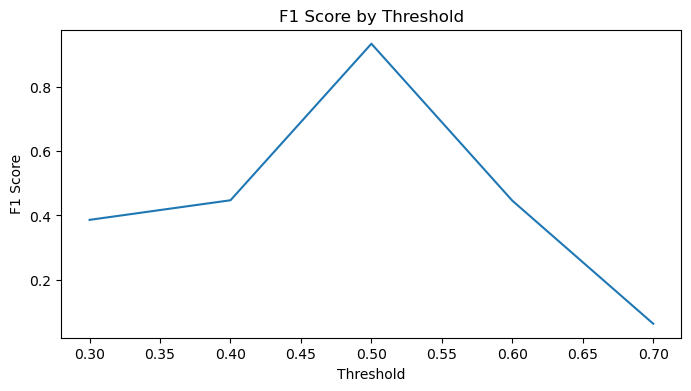

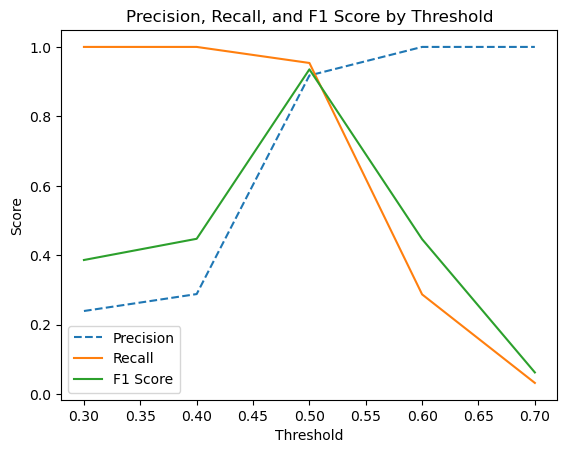

In [12]:
# AdaBoost was the best-performing model in (9)
y_proba_best = y_proba_under_ada

y_pred_03 = (y_proba_best >= 0.3).astype(int)
y_pred_04 = (y_proba_best >= 0.4).astype(int)
y_pred_05 = (y_proba_best >= 0.5).astype(int)
y_pred_06 = (y_proba_best >= 0.6).astype(int)
y_pred_07 = (y_proba_best >= 0.7).astype(int)

threshold_result = pd.DataFrame({'Threshold': [0.3, 0.4, 0.5, 0.6, 0.7],
    'Precision': [
        precision_score(y_test, y_pred_03),
        precision_score(y_test, y_pred_04),
        precision_score(y_test, y_pred_05),
        precision_score(y_test, y_pred_06),
        precision_score(y_test, y_pred_07)],
    'Recall': [
        recall_score(y_test, y_pred_03),
        recall_score(y_test, y_pred_04),
        recall_score(y_test, y_pred_05),
        recall_score(y_test, y_pred_06),
        recall_score(y_test, y_pred_07)],
    'F1 Score': [
        f1_score(y_test, y_pred_03),
        f1_score(y_test, y_pred_04),
        f1_score(y_test, y_pred_05),
        f1_score(y_test, y_pred_06),
        f1_score(y_test, y_pred_07)]})
print(threshold_result)

plt.figure(figsize=(8,4))
plt.plot(threshold_result['Threshold'], threshold_result['F1 Score'])
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score by Threshold')
plt.show()

plt.plot(threshold_result['Threshold'], threshold_result['Precision'], linestyle='--', label='Precision')
plt.plot(threshold_result['Threshold'], threshold_result['Recall'], label='Recall')
plt.plot(threshold_result['Threshold'], threshold_result['F1 Score'], label='F1 Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score by Threshold')
plt.legend()
plt.show()

### Interpretation
For the AdaBoost model, I changed the classification threshold from 0.3 ~ 0.7 and calculated precision, recall, and F1 score for each threshold.
When the threshold was 0.3 or 0.4, recall was 1.0000, meaning that the model identified all resigned employees. However, precisions were very low (0.2394 and 0.2881, respectively), so many non-resigned employees were incorrectly predicted as resigned in lower threshold.
When the threshold was 0.6 or 0.7, precision was 1.0000, but recall decreased sharply. This means that the model became too conservative and missed many employees who actually resigned.
The F1 score was highest at the threshold of 0.5, with an F1 score of 0.9354. Therefore, I suggest using the default threshold of 0.5 for the AdaBoost model because it provides the best balance between precision and recall.
Additionally, I provide the plot that also shows the trade-off between precision and recall. At lower thresholds, recall is high but precision is low. At higher thresholds, precision is high but recall becomes very low. The F1 score is highest at the threshold of 0.5, so this threshold provides the best balance between precision and recall.

# (11) Based on the results in (9), state which model performs the best and explain why that model was able to predict the resign data well.

In [13]:
print("Confusion Matrix of AdaBoost:")
print(confusion_matrix(y_test, y_pred_under_ada))

print("Classification Report of AdaBoost:")
print(classification_report(y_test, y_pred_under_ada))

Confusion Matrix of AdaBoost:
[[2225   61]
 [  33  681]]
Classification Report of AdaBoost:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2286
           1       0.92      0.95      0.94       714

    accuracy                           0.97      3000
   macro avg       0.95      0.96      0.96      3000
weighted avg       0.97      0.97      0.97      3000



### Interpretation
Based on the results in (9), `AdaBoost` performed the best among the four models. It achieved the highest F1 score, 0.9354, with precision of 0.9178 and recall of 0.9538 for class 1.
The confusion matrix also supports this result. Among 714 employees who actually resigned, `AdaBoost` correctly predicted 681 employees as resigned and missed only 33 employees. This means that the model was very effective at identifying employees who actually resigned.
`AdaBoost` was able to predict the resign data well because it combines multiple decision trees sequentially. Each new tree focuses more on observations that were misclassified by previous trees. This helps the model capture complex patterns in the data, such as combinations of satisfaction, evaluation, years, project, and workhour.
Overall, `AdaBoost` provided the best balance between precision and recall. Therefore, AdaBoost was selected as the best-performing model for predicting employee resignation.